 Avocast Project 
 Import of datasets 
Definition of Prophet : a procedure for forecasting time series data based on an additive model where non-linear trends are fit with yearly, weekly, and daily seasonality. (for forecasts)
 Definition of Pandas is a Python package that provides fast, flexible, and expressive data structures designed to make working with "relational" or "labeled" data both easy and intuitive.(is going to be used like Excel)
 Dataset avocast includes daily data about avocado prices in US. 

In [12]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
from prophet.plot import add_changepoints_to_plot

In [13]:
#Loading dataset for making predictions 
df=pd.read_csv('avocado.csv')
number_of_rows = len(df)
number_of_columns = len(df.columns)
print("File uploaded!")
print(f"All rows: {number_of_rows}")
print(f"All columns: {number_of_columns}")
print("\n First 10 data rows")
print(df.head(10))

File uploaded!
All rows: 18249
All columns: 14

 First 10 data rows
   Unnamed: 0        Date  AveragePrice  Total Volume     4046       4225  \
0           0  2015-12-27          1.33      64236.62  1036.74   54454.85   
1           1  2015-12-20          1.35      54876.98   674.28   44638.81   
2           2  2015-12-13          0.93     118220.22   794.70  109149.67   
3           3  2015-12-06          1.08      78992.15  1132.00   71976.41   
4           4  2015-11-29          1.28      51039.60   941.48   43838.39   
5           5  2015-11-22          1.26      55979.78  1184.27   48067.99   
6           6  2015-11-15          0.99      83453.76  1368.92   73672.72   
7           7  2015-11-08          0.98     109428.33   703.75  101815.36   
8           8  2015-11-01          1.02      99811.42  1022.15   87315.57   
9           9  2015-10-25          1.07      74338.76   842.40   64757.44   

     4770  Total Bags  Small Bags  Large Bags  XLarge Bags          type  \
0   48.1

In [14]:
#Making a list with the names of important columns for analysis. 
#Studing the data, what characteristics are there, how many different values, and whether there are any gaps. 
print ( "All colums in the data:")
for number, column in enumerate(df.columns,1):
    print(f"{number}.{column}")

import_columns =['Date','AveragePrice', 'Type','Region']
print("\n Key colomns for analysis:")
for column in df.columns:
   if column in import_columns:
      unique_count= df[column].nunique()
      print (f"{column}: {unique_count} unique values")


missing_values = df.isnull().sum().sum()
print (f"\n Missing values: {missing_values}")      


All colums in the data:
1.Unnamed: 0
2.Date
3.AveragePrice
4.Total Volume
5.4046
6.4225
7.4770
8.Total Bags
9.Small Bags
10.Large Bags
11.XLarge Bags
12.type
13.year
14.region

 Key colomns for analysis:
Date: 169 unique values
AveragePrice: 259 unique values

 Missing values: 0


In [15]:
#Choosing the region from the data
region= "California"
region_data= df[df['region']==region].copy()
print (f"Selected region: {region}")
print (f"Data for {region}: {len(region_data)} row")

Selected region: California
Data for California: 338 row


I chose California, I chose California because it is "the largest domestic producer of avocados."(p.4)  (Hammami, A.Malek & Huang, Kuan-Ming & Guan, Zhengfei. (2024). Overview of the Avocado Market in the United States: FE1150, 8/2024. EDIS. 2024. 10.32473/edis-fe1150-2024. ) 
The selection of the region is explained in more details in the report.

In [16]:
## Prophet requires specific column names:
# 'ds' for date, 'y' for the values we're predicting
prepared_data = region_data[['Date','AveragePrice']].copy()
#rename columns
prepared_data.columns = ['ds','y']
#astype('datetime64[ns]') converts text to datetime. Convert data to proper for Prophet format
prepared_data['ds'] = prepared_data['ds'].astype('datetime64[ns]')
prepared_data = prepared_data.sort_values('ds')
print("Data prepared for Prophet model")
print(f"Period:{ prepared_data['ds'].min().date()}-{prepared_data['ds'].max()}")
print(f"Prices: from ${prepared_data['y'].min():.2f} to ${prepared_data['y'].max():.2f}")
print(f"Average price: ${prepared_data['y'].mean():.2f}")
print(f"Number of data points:{len(prepared_data)}")
print(f"Days in dataset: {prepared_data['ds'].max()-prepared_data['ds'].min()}")


# Resample to weekly frequency
prepared_data = prepared_data.set_index('ds').resample('W').mean().reset_index()

# Fill missing dates
full_date_range = pd.date_range(
    start=prepared_data['ds'].min(),
    end=prepared_data['ds'].max(),
    freq='W'
)
missing_dates = full_date_range.difference(prepared_data['ds'])
print(f"Missing weeks: {len(missing_dates)}")

if len(missing_dates) > 0:
    missing_df = pd.DataFrame({'ds': list(missing_dates)})
    prepared_data = pd.concat([prepared_data, missing_df], ignore_index=True)
    prepared_data = prepared_data.sort_values('ds')
    prepared_data['y'] = prepared_data['y'].ffill().bfill()

Data prepared for Prophet model
Period:2015-01-04-2018-03-25 00:00:00
Prices: from $0.67 to $2.58
Average price: $1.40
Number of data points:338
Days in dataset: 1176 days 00:00:00
Missing weeks: 0


The step below is necessary to evaluate the performance of the model. Knowing how exactly the model works is important so that you don't make mistakes with financial and technical solutions.

In [17]:
#Here the tools to analyze how accurate the forecasts are
#Preparing the data for the model
def count_mae(actual_values, predicted_values):
    #Calculate Mean Absolute Error (mae) e.g. how many dollars the model is wrong by
    total_error = 0 
    
    for actual, predicted in zip(actual_values, predicted_values):
        total_error += abs(actual-predicted)
    return total_error/ len(actual_values)

def count_mape(actual_values, predicted_values):
   #Calculates Mean Absolute Percentage Error (MAPE) =  on average by what percentage the model is wrong

    total_percentage = 0
    count = 0
    
    for actual, predicted in zip(actual_values, predicted_values):
        if actual != 0:  
            # Calculate error percentage 
            error = abs((actual - predicted) / actual)
            total_percentage += error
            count += 1
    
    if count > 0:
        # get percentage
        return (total_percentage / count) * 100
    else:
        return 0

In [18]:
# Here we divide data to train the Prophet model
# 80% for training, 20% for testing
train_size = int(len(prepared_data) * 0.8)

# Training set (first 80%)
training_set = prepared_data[:train_size]

# Testing set (last 20%)
testing_set = prepared_data[train_size:]

print(f"Dataset divided:")
print(f"Training data: {len(training_set)} rows (80%)")
print(f"Testing data: {len(testing_set)} rows (20%)")


# Train the Prophet model now that training_set is defined
model = Prophet()

# Here the time-series prototype that predicts weekly avocado prices for a selected U.S. region using the Prophet library is created Create Prophet model with settings

model = Prophet(

    yearly_seasonality=True,   # Consider annual seasons

    weekly_seasonality=True,   # Consider weekly cycles

    daily_seasonality=False    # Don't consider daily cycles 
)


# Add US holiday information

# it will change price during holidays 
model.add_country_holidays(country_name='US')
print("Prophet model created. Training will run after the dataset is split.")
model.fit(training_set)

print("Model successfully trained!")



Dataset divided:
Training data: 135 rows (80%)
Testing data: 34 rows (20%)
Prophet model created. Training will run after the dataset is split.


00:02:04 - cmdstanpy - INFO - Chain [1] start processing
00:02:04 - cmdstanpy - INFO - Chain [1] done processing


Model successfully trained!


Here the time-series prototype that predicts weekly avocado prices for a selected U.S. region using the Prophet library is created 

In [19]:

#Testing if prototipe works
# periods=how many weeks ahead to forecast
# freq='W' === weekly frequency
future_dates = model.make_future_dataframe(
    periods=len(testing_set),
    freq='W'
)

# Predict prices for these dates
forecast = model.predict(future_dates)

print(f"A forecast is created  for {len(testing_set)} weeks in advance ")
print(" Forecast results saved")

A forecast is created  for 34 weeks in advance 
 Forecast results saved


Testing if prototipe works

In [ ]:
# Choose only the data from forecast that exist in testing_set

# forecast contains: 2015-2018 (all historical data) + 68 weeks of forecast
# testing_set contains only: 2017-2018 (test period)

future_forecast = forecast.tail(len(testing_set))

print(f"Test data: {len(testing_set)} records")
print(f" Period: {testing_set['ds'].min().date()} - {testing_set['ds'].max().date()}")
print(f"Forecast (future only): {len(future_forecast)} records")
print(f" Period: {future_forecast['ds'].min().date()} - {future_forecast['ds'].max().date()}")

# Check that the number of dates matches
if len(testing_set) == len(future_forecast):  
    # Check if dates actually match (not just count)
    dates_match = testing_set['ds'].min().date() == future_forecast['ds'].min().date()
    
    if dates_match:
        # Calculate how much the forecast differs from reality
        mae = count_mae(testing_set['y'], future_forecast['yhat'])  
        mape = count_mape(testing_set['y'], future_forecast['yhat'])  
        
        print("\n Accuracy evaluation results:")
        print(f" Average error in dollars: ${mae:.3f}")
        print(f" Average error percentage: {mape:.1f}%")

        # Interpret the results
        if mape < 10:
            print(" Excellent accuracy! (error less than 10%)")
        elif mape < 20:
            print(" Good accuracy! (error 10-20%)")
        else:
            print(" Acceptable accuracy for price forecasting")
    else:
        print("\n Dates don't match exactly!")
        print(f" Test starts: {testing_set['ds'].min().date()}")
        print(f" Forecast starts: {future_forecast['ds'].min().date()}")
else:
    print("\nCould not compare forecast with actual data")
    print(f" Test data count: {len(testing_set)}")
    print(f" Forecast count: {len(future_forecast)}")

Test data: 34 records
 Period: 2017-08-06 - 2018-03-25
Forecast (future only): 34 records
 Period: 2017-08-06 - 2018-03-25

 Accuracy evaluation results:
 Average error in dollars: $0.173
 Average error percentage: 11.0%
 Good accuracy! (error 10-20%)


Comparing the forecast with real data and generating visualisation


Generating visualizations...


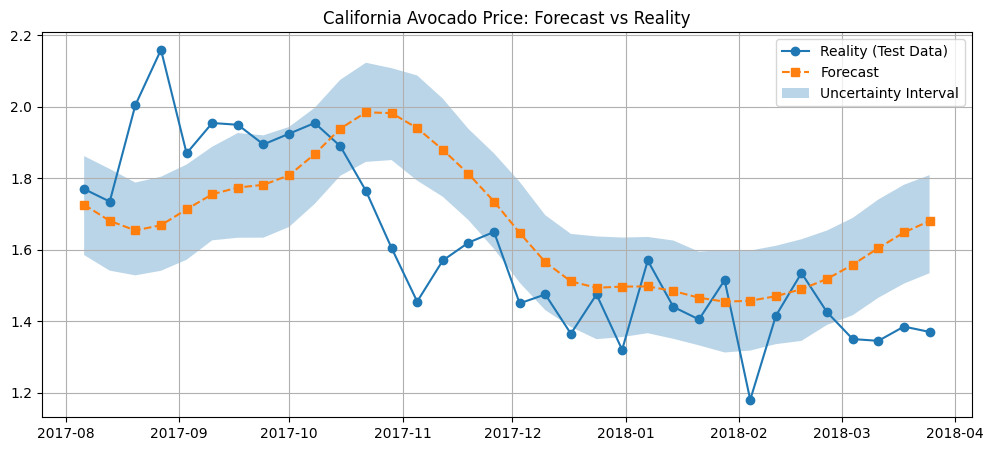

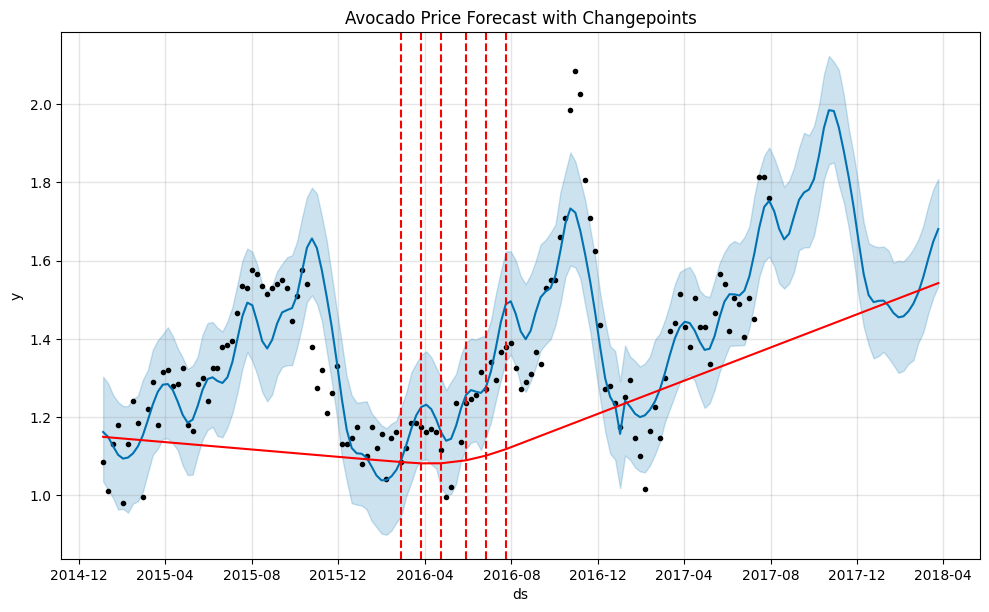

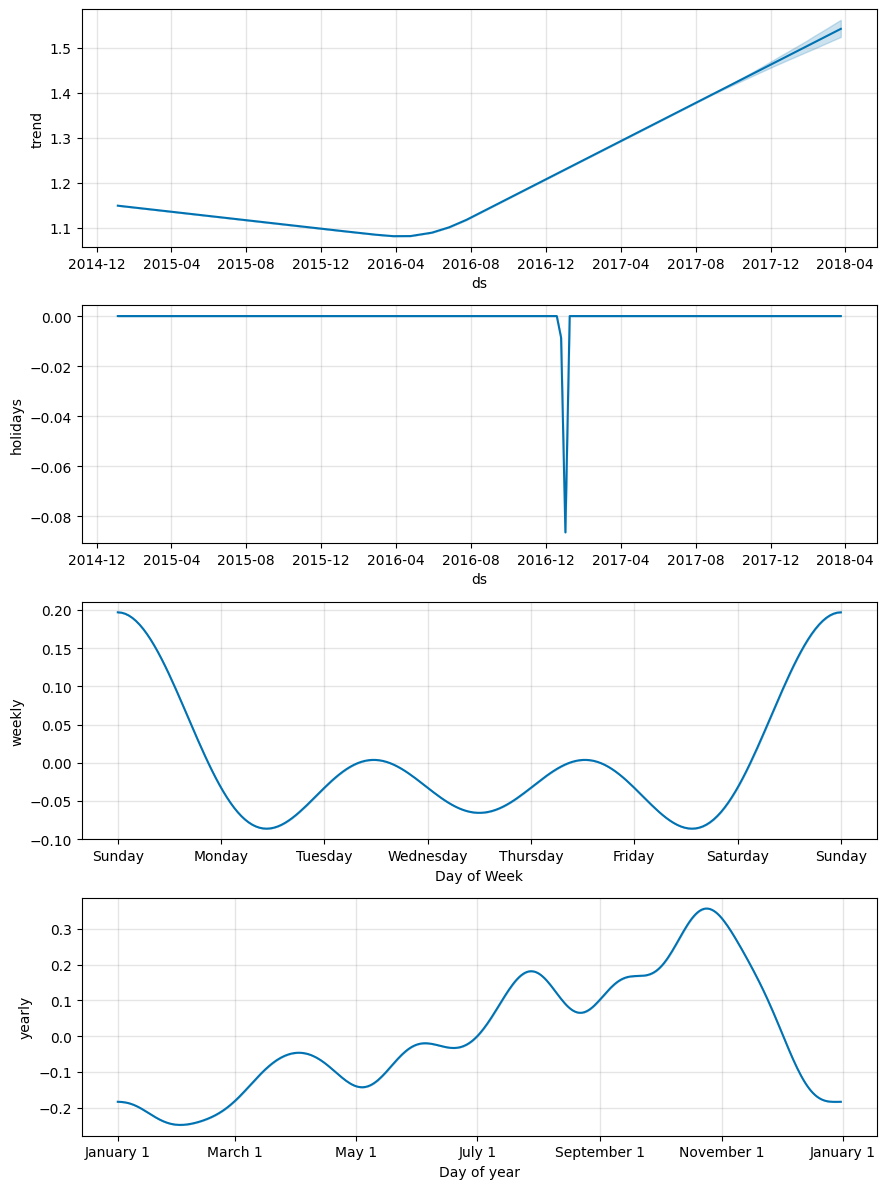

Forecast vs Reality


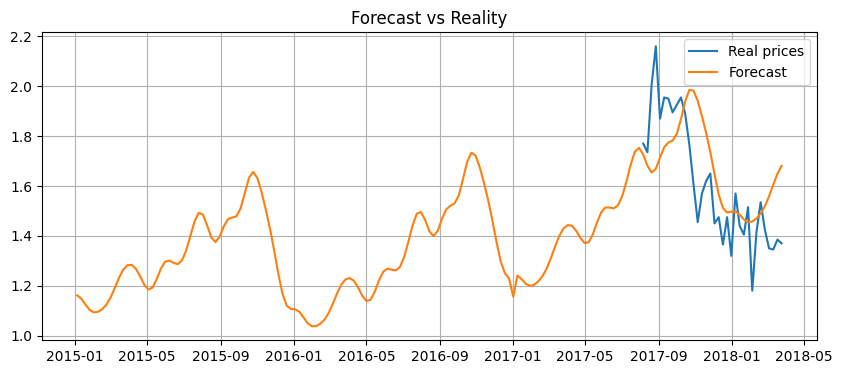


 Forecast with Uncertainty


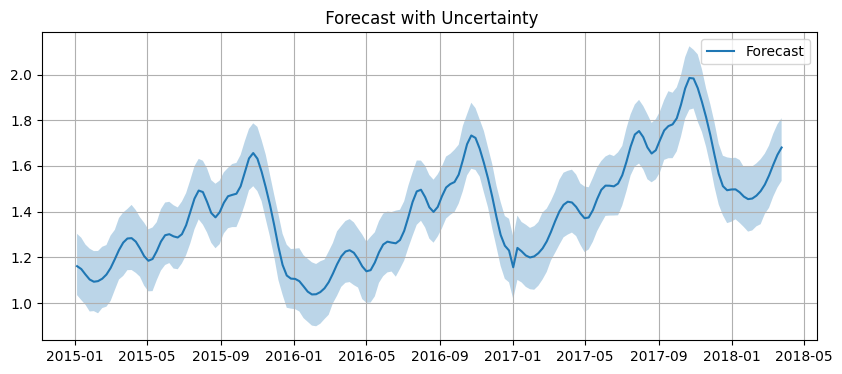


 Detailed comparison


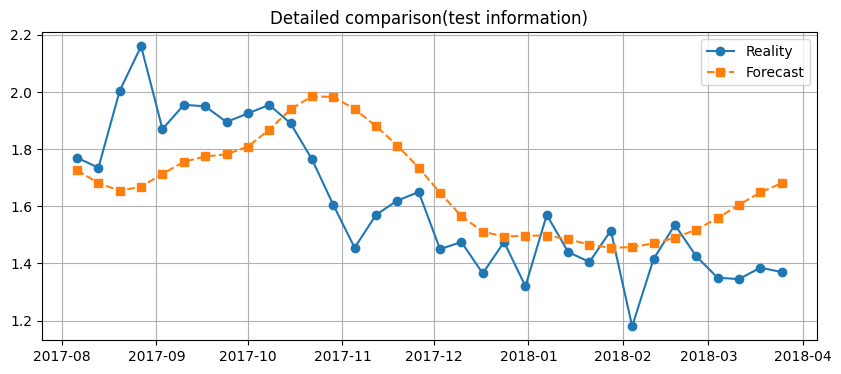


 Results
MAE: $0.173
MAPE: 11.0%
Test data: 34
Good accuracy


In [21]:

print("\nGenerating visualizations...")
plt.figure(figsize=(12, 5))
plt.plot(testing_set['ds'], testing_set['y'], 'o-', label='Reality (Test Data)')
plt.plot(future_forecast['ds'], future_forecast['yhat'], 's--', label='Forecast')
plt.fill_between(future_forecast['ds'], future_forecast['yhat_lower'], future_forecast['yhat_upper'], alpha=0.3, label='Uncertainty Interval')
plt.title(f'{region} Avocado Price: Forecast vs Reality')
plt.legend()
plt.grid(True)
plt.show()


fig = model.plot(forecast)
add_changepoints_to_plot(fig.gca(), model, forecast) 
plt.title("Avocado Price Forecast with Changepoints")
plt.show()


fig2 = model.plot_components(forecast)
plt.show()

print("Forecast vs Reality")
plt.figure(figsize=(10, 4))
plt.plot(testing_set['ds'], testing_set['y'], label='Real prices')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast')
plt.title('Forecast vs Reality')
plt.legend()
plt.grid(True)
plt.show()

print("\n Forecast with Uncertainty")
plt.figure(figsize=(10, 4))
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], alpha=0.3)
plt.title(' Forecast with Uncertainty')
plt.legend()
plt.grid(True)
plt.show()

print("\n Detailed comparison")
plt.figure(figsize=(10, 4))
test_forecast = forecast.tail(len(testing_set))
plt.plot(testing_set['ds'], testing_set['y'], 'o-', label='Reality')
plt.plot(test_forecast['ds'], test_forecast['yhat'], 's--', label='Forecast')
plt.title('Detailed comparison(test information)')
plt.legend()
plt.grid(True)
plt.show()

print("\n Results")
print("=" * 40)
print(f"MAE: ${mae:.3f}")
print(f"MAPE: {mape:.1f}%")
print(f"Test data: {len(testing_set)}")
if mape < 10:
    print("Excellent accuracy")
elif mape < 20:
    print("Good accuracy")
else:
    print("Normal accuracy")
print("=" * 40)

In [22]:
print("\n Recommendations based on the results of forecasting:")
print("=" * 60)

# RECOMMENDATIONS BASED ON ACCURACY
if 'mape' in locals():
    print(f" Forecast accuracy: {mape:.1f}%")
    
    if mape < 10:
        print(" Excellent accuracy -  the forecast can be trasted:")
        print("""
        1.  CONFIDENT PLANNING
            Sign long-term contracts based on forecasts
            Invest in inventory increases during low-price periods
        
        2.  ACTIVE PRICING  
            Set fixed prices 3-6 months in advance
            Offer customers guaranteed prices
        """)
        
    elif mape < 20:
        print(" Good accuracy - should be used with caution:")
        print("""
        1.  MODERATE PLANNING
            Plan purchases 1-3 months ahead
            Maintain 10-15% safety stock
        
        2.  FLEXIBLE PRICING
            Set price ranges (e.g., $1.50-1.70)
            Use floating prices with adjustments
        """)
        
    else:
        print(" Normal accuracy - should be used as guidance only:")
        print("""
        1.  CONSERVATIVE PLANNING
            Plan only for the upcoming month
            Increase safety stock to 20-25%
        
        2. CAUTIOUS PRICING
            Review prices more frequently (every 2 weeks)
            Use forecast only for general trend direction
        """)

# GENERAL RECOMMENDATIONS FOR ALL CASES
print("""
3.  UNIVERSAL STRATEGIES:
    Always diversify suppliers
    Use futures contracts for risk hedging
    Monitor not only prices but also demand volumes

4. PROCESS RECOMMENDATIONS:
    Establish regular forecast review process (weekly)
    Maintain a log of actual vs forecasted prices
    Gradually increase trust in the model as data accumulates
""")


 Recommendations based on the results of forecasting:
 Forecast accuracy: 11.0%
 Good accuracy - should be used with caution:

        1.  MODERATE PLANNING
            Plan purchases 1-3 months ahead
            Maintain 10-15% safety stock

        2.  FLEXIBLE PRICING
            Set price ranges (e.g., $1.50-1.70)
            Use floating prices with adjustments
        

3.  UNIVERSAL STRATEGIES:
    Always diversify suppliers
    Use futures contracts for risk hedging
    Monitor not only prices but also demand volumes

4. PROCESS RECOMMENDATIONS:
    Establish regular forecast review process (weekly)
    Maintain a log of actual vs forecasted prices
    Gradually increase trust in the model as data accumulates

